# Optimizing Fire Station Expansion in Istanbul

**YZV202E Optimization for Data Science**

This notebook implements the project proposal using a reproducible location-allocation pipeline. The primary model is a fixed-existing-station weighted p-median formulation. Following the instructor feedback, the notebook also evaluates district-level service gaps and uses one consistent travel-time metric in minutes throughout the discrete and continuous stages.

## 1. Setup

The project code is organized under `src/istanbul_fire_opt`. Optional packages such as `PuLP`, `OSMnx`, `folium`, and `ipywidgets` improve the experience, but the core notebook runs with the fallback exact enumerator and calibrated minute proxy.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd
import matplotlib.pyplot as plt

from istanbul_fire_opt.workflow import (
    build_problem,
    baseline_solution,
    run_budget_experiment,
    assignment_frame,
    selected_sites_frame,
)
from istanbul_fire_opt.optimization import (
    bisection_min_budget,
    equity_sensitivity,
    solution_table,
    solve_equity_refinement,
    solve_p_median_milp,
    validate_solution,
)
from istanbul_fire_opt.heuristics import genetic_algorithm, simulated_annealing
from istanbul_fire_opt.continuous import continuous_results_frame, refine_site_location
from istanbul_fire_opt.visualization import plot_coverage, plot_method_comparison, plot_solution_map

pd.set_option("display.max_colwidth", 140)

## 2. Data Preparation

The data layer downloads and caches official IBB files:

- Fire station coordinates.
- District population from the IBB/TUIK population table.
- Average fire-event arrival time for calibration.
- First-degree emergency transportation roads.
- Mukhtar office locations, aggregated into district centroids.

The project uses population as the primary demand weight. The official fire-count sheets found during implementation are city-level rather than district-level, so they are used as contextual evidence instead of district weights.

In [2]:
data, problem, travel_model = build_problem(prefer_road_network=False)
print(data.metadata)
print("Travel-time model:", travel_model.mode)
print(travel_model.note)
display(problem.demand.head())
display(problem.all_sites.head())

{'station_count': 136, 'district_count': 39, 'neighborhood_count': 963, 'arrival_minutes_target': 6.983333333333334, 'source_titles': {'fire_stations_2025': 'IBB Fire Station Location Data 2025', 'population': 'IBB/TUIK Population Information', 'arrival_time': 'IBB Fire Event Average Arrival Time', 'emergency_roads': 'IBB First-degree Emergency Transportation Roads', 'muhtarlik_locations': 'IBB Mukhtar Office Address Locations', 'fire_counts': 'IBB Fire Counts'}}
Travel-time model: calibrated_geometric
Calibrated geometric proxy in minutes. This fallback is used because full road-routing dependencies/data are optional; no raw Euclidean distance objective is mixed into the optimization.


,demand_id,district,district_key,population_year,population,weight,lon,lat,neighborhood_count
0,demand_00,Adalar,adalar,2025,17489,17489.0,29.096010,40.882916,5
1,demand_01,Arnavutköy,arnavutkoy,2025,358469,358469.0,28.698111,41.207489,38
2,demand_02,Ataşehir,atasehir,2025,412125,412125.0,29.121620,40.990546,17
3,demand_03,Avcılar,avcilar,2025,440663,440663.0,28.718688,41.000063,10
4,demand_05,Bahçelievler,bahcelievler,2025,539035,539035.0,28.843566,41.004911,11


,site_id,site_name,district,district_key,lon,lat,is_existing
0,existing_000,Beyoğlu İtfaiye İstasyonu,Şişli,sisli,28.990542,41.048385,True
1,existing_001,Mecidiyeköy İtfaiye İstasyonu,Şişli,sisli,28.997427,41.065136,True
2,existing_002,Beşiktaş İtfaiye İstasyonu,Beşiktaş,besiktas,29.019198,41.048908,True
3,existing_003,Ortaköy İtfaiye İstasyonu,Beşiktaş,besiktas,29.041893,41.069590,True
4,existing_004,Seyrantepe İtfaiye İstasyonu,Kağıthane,kagithane,28.988800,41.095948,True


## 3. Consistent Travel-Time Metric

The objective is measured in minutes. If road-network routing is available, the same `TravelTimeModel` interface can return shortest-path road times. In this local environment, the notebook uses a calibrated geometric proxy: district-to-site distances are converted to minutes and scaled so the current network's weighted average response matches IBB's published average arrival time. The continuous refinement stage uses this same minute-scale interface, not raw Euclidean distance.

,method,p,weighted_avg_min,max_min,p90_min,coverage_5,coverage_8,runtime_s,opened_sites
0,Current network baseline,0,6.983333,22.496748,12.939041,0.37693,0.604159,0.0,


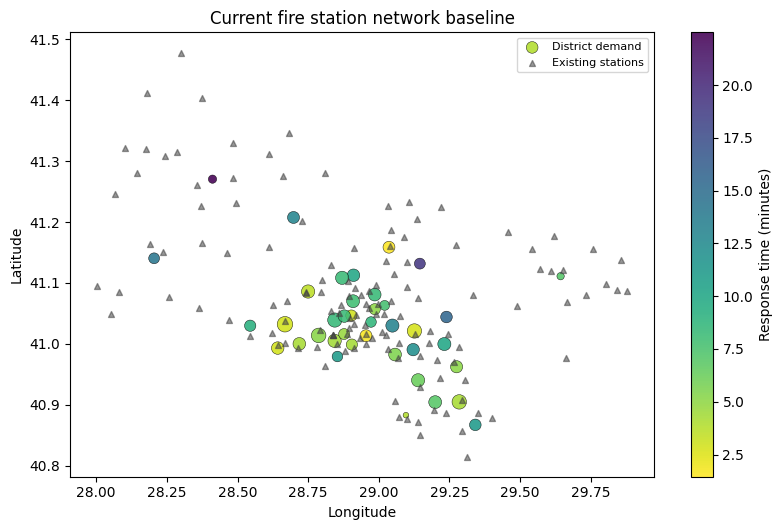

In [3]:
current = baseline_solution(problem)
display(solution_table(problem, [current]))
plot_solution_map(problem, current, title="Current fire station network baseline")
plt.show()

## 4. P-Median and Equity Refinement

The first model minimizes total weighted response time. The second model follows the instructor feedback by reducing district-level gaps: it minimizes the worst assigned district response time while keeping total weighted response time within `epsilon = 2%` of the p-median optimum.

,method,p,weighted_avg_min,max_min,p90_min,coverage_5,coverage_8,runtime_s,opened_sites
0,Current network baseline,0,6.983333,22.496748,12.939041,0.376930,0.604159,0.000000,
1,MILP exact fallback (enumeration),3,5.858329,22.496748,12.082252,0.486707,0.713935,0.067444,Candidate station - Bağcılar; Candidate station - Sancaktepe; Candidate station - Üsküdar
2,Equity-refined p-median,3,5.929909,22.496748,10.036794,0.455791,0.683019,0.068959,Candidate station - Ataşehir; Candidate station - Çekmeköy; Candidate station - Üsküdar


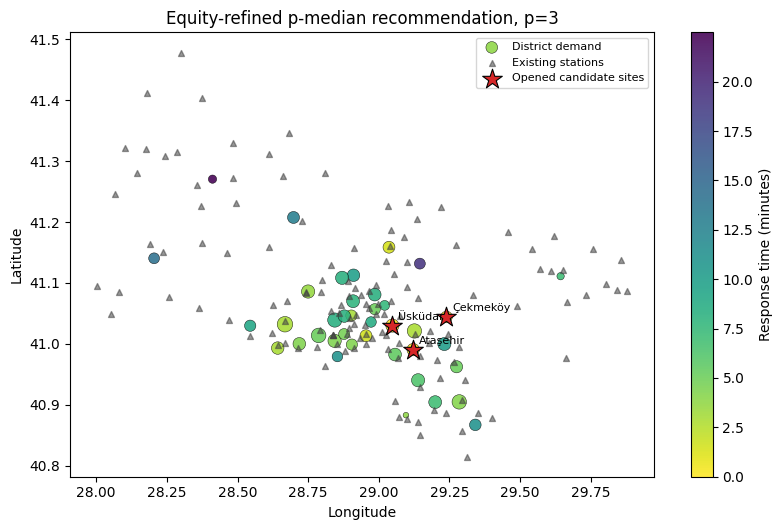

,district,population,demand_lon,demand_lat,assigned_site,assigned_site_district,response_minutes
33,Çatalca,81143,28.411421,41.270373,İhsaniye Gönüllü İtfaiye istasyonu,Çatalca,22.496748
9,Beykoz,246833,29.145231,41.131714,Beykoz İtfaiye İstasyonu,Beykoz,19.115886
28,Silivri,240029,28.204794,41.140451,Büyükkılıçlı Mahallesi Gönüllü İtfaiye İstasyonu,Silivri,14.211338
1,Arnavutköy,358469,28.698111,41.207489,Arnavutköy İtfaiye İstasyonu,Arnavutköy,12.939041
31,Tuzla,313865,29.341505,40.867012,Orhanlı İtfaiye İstasyonu,Tuzla,11.080537
5,Bakırköy,218204,28.853577,40.979239,Siyavuşpaşa İtfaiye İstasyonu,Bahçelievler,11.046483
26,Sancaktepe,507500,29.231944,40.999710,Sancaktepe İtfaiye İstasyonu,Sancaktepe,10.036794
16,Eyüpsultan,425216,28.910415,41.112634,Sultangazi İtfaiye İstasyonu,Sultangazi,9.931725
13,Büyükçekmece,283239,28.544782,41.029767,Büyükçekmece İtfaiye İstasyonu,Büyükçekmece,9.176662
11,Beyoğlu,215991,28.972418,41.035886,Balat İtfaiye İstasyonu,Fatih,8.763533


In [4]:
p = 3
epsilon = 0.02

p_median = solve_p_median_milp(problem, p)
equity = solve_equity_refinement(problem, p, p_median_solution=p_median, epsilon=epsilon)
validate_solution(problem, p_median)
validate_solution(problem, equity)

comparison = solution_table(problem, [current, p_median, equity])
display(comparison)
plot_solution_map(problem, equity, title=f"Equity-refined p-median recommendation, p={p}")
plt.show()
display(assignment_frame(problem, equity).sort_values("response_minutes", ascending=False).head(10))

## 5. Interactive Scenario Controls

Use the controls to change the budget, method, equity tolerance, and coverage threshold. If `ipywidgets` is not installed, the same function can still be called manually.

ipywidgets is unavailable; running a default scenario instead.
ModuleNotFoundError No module named 'ipywidgets'
Weighted coverage at 8 min: 68.3%


,method,p,weighted_avg_min,max_min,p90_min,coverage_5,coverage_8,runtime_s,opened_sites
0,Equity-refined p-median,3,5.929909,22.496748,10.036794,0.455791,0.683019,0.066834,Candidate station - Ataşehir; Candidate station - Çekmeköy; Candidate station - Üsküdar


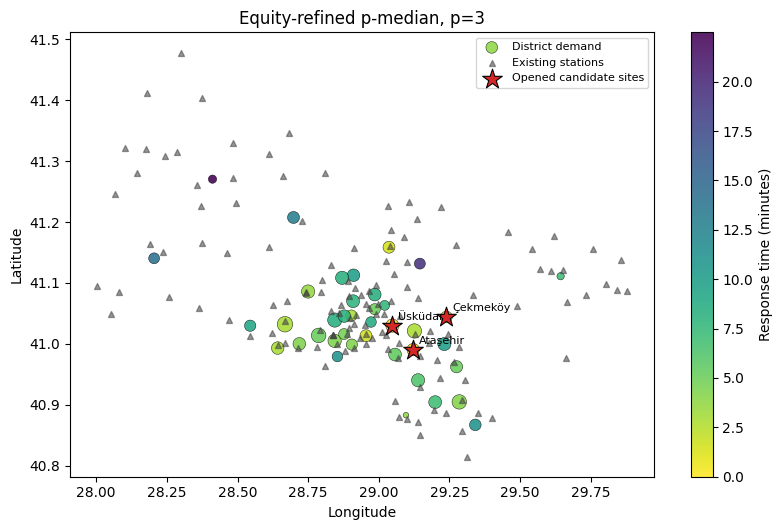

In [5]:
def run_scenario(p=3, method="Equity-refined p-median", epsilon=0.02, threshold_minutes=8.0):
    base = solve_p_median_milp(problem, int(p))
    if method == "Pure p-median":
        solution = base
    elif method == "GA equity-aware":
        bound = base.metrics["weighted_average_minutes"] * (1 + epsilon)
        solution = genetic_algorithm(problem, int(p), equity_bound_minutes=bound, epsilon=epsilon, generations=80)
    elif method == "SA equity-aware":
        bound = base.metrics["weighted_average_minutes"] * (1 + epsilon)
        solution = simulated_annealing(problem, int(p), equity_bound_minutes=bound, epsilon=epsilon, iterations=1600)
    else:
        solution = solve_equity_refinement(problem, int(p), p_median_solution=base, epsilon=epsilon)

    table = solution_table(problem, [solution])
    coverage_key = f"coverage_{str(float(threshold_minutes)).replace('.', '_')}_minutes"
    if coverage_key in solution.metrics:
        print(f"Weighted coverage at {threshold_minutes:g} min:", f"{solution.metrics[coverage_key]:.1%}")
    display(table)
    plot_solution_map(problem, solution, title=f"{method}, p={p}")
    plt.show()
    return solution

try:
    import ipywidgets as widgets
    from IPython.display import display as ipy_display

    controls = widgets.interactive(
        run_scenario,
        p=widgets.IntSlider(value=3, min=1, max=5, step=1, description="p"),
        method=widgets.Dropdown(
            options=["Equity-refined p-median", "Pure p-median", "GA equity-aware", "SA equity-aware"],
            value="Equity-refined p-median",
            description="method",
        ),
        epsilon=widgets.FloatSlider(value=0.02, min=0.0, max=0.20, step=0.01, readout_format=".0%", description="epsilon"),
        threshold_minutes=widgets.Dropdown(options=[5.0, 8.0], value=8.0, description="Tmax"),
    )
    ipy_display(controls)
except Exception as exc:
    print("ipywidgets is unavailable; running a default scenario instead.")
    print(type(exc).__name__, exc)
    _ = run_scenario()

## 6. Extended Analysis: Exact, GA, and SA Comparison

This experiment compares exact p-median, equity-refined p-median, Genetic Algorithm, and Simulated Annealing for the proposal budgets `p in {1, 3, 5}`. The key evaluation columns are weighted average response time, worst district response time, P90 response time, and weighted demand coverage under 5 and 8 minutes.

,method,p,weighted_avg_min,max_min,p90_min,coverage_5,coverage_8,runtime_s,opened_sites
0,Current network baseline,0,6.983333,22.496748,12.939041,0.376930,0.604159,0.000000,
1,MILP exact fallback (enumeration),1,6.557052,22.496748,12.082252,0.409576,0.636804,0.000356,Candidate station - Üsküdar
2,Equity-refined p-median,1,6.557052,22.496748,12.082252,0.409576,0.636804,0.000326,Candidate station - Üsküdar
3,GA equity-aware,1,6.557052,22.496748,12.082252,0.409576,0.636804,2.344152,Candidate station - Üsküdar
4,SA equity-aware,1,6.557052,22.496748,12.082252,0.409576,0.636804,0.092564,Candidate station - Üsküdar
5,MILP exact fallback (enumeration),3,5.858329,22.496748,12.082252,0.486707,0.713935,0.065349,Candidate station - Bağcılar; Candidate station - Sancaktepe; Candidate station - Üsküdar
6,Equity-refined p-median,3,5.929909,22.496748,10.036794,0.455791,0.683019,0.064519,Candidate station - Ataşehir; Candidate station - Çekmeköy; Candidate station - Üsküdar
7,GA equity-aware,3,5.951564,22.496748,10.036794,0.452385,0.679614,2.371767,Candidate station - Arnavutköy; Candidate station - Çekmeköy; Candidate station - Üsküdar
8,SA equity-aware,3,5.951564,22.496748,10.036794,0.452385,0.679614,0.091647,Candidate station - Arnavutköy; Candidate station - Çekmeköy; Candidate station - Üsküdar
9,MILP exact fallback (enumeration),5,5.231186,22.496748,9.931725,0.532923,0.760151,4.330542,Candidate station - Ataşehir; Candidate station - Bağcılar; Candidate station - Sancaktepe; Candidate station - Çekmeköy; Candidate stat...


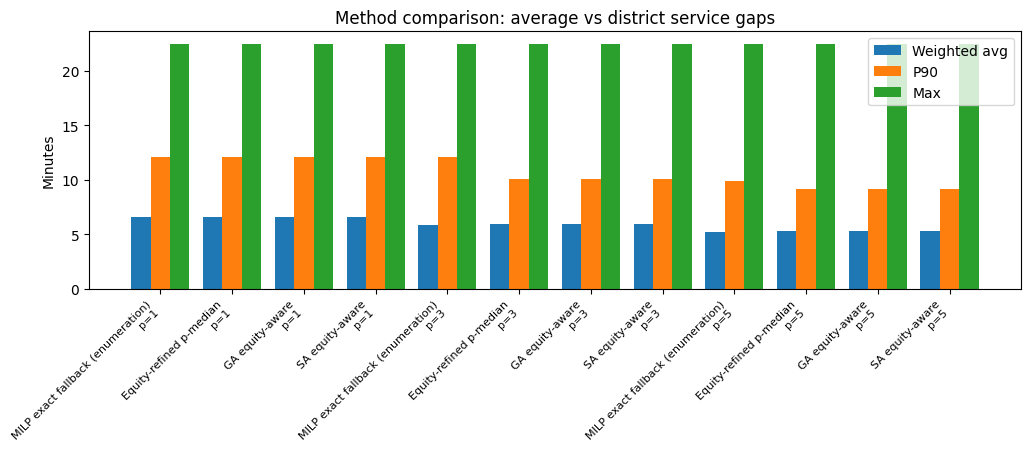

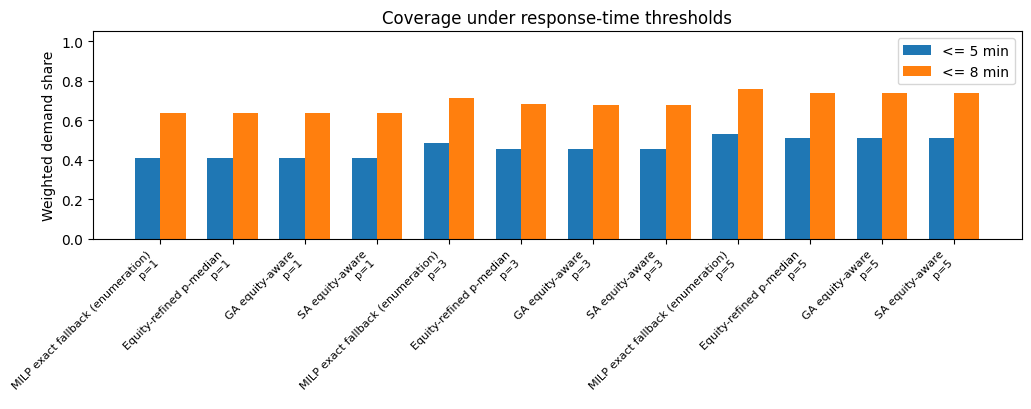

In [6]:
results, solutions = run_budget_experiment(problem, budgets=(1, 3, 5), epsilon=0.02, include_heuristics=True)
display(results)
plot_method_comparison(results)
plt.show()
plot_coverage(results)
plt.show()

## 7. Equity Sensitivity

A strict `epsilon = 2%` average-time tolerance may not fully reduce the worst district if the worst-served area has relatively low population. This table makes that tradeoff explicit instead of hiding it inside the average objective.

In [7]:
sensitivity = equity_sensitivity(problem, p=5, epsilons=(0.0, 0.02, 0.05, 0.10, 0.20))
display(sensitivity)

,epsilon,allowed_average_min,weighted_average_min,max_min,p90_min,coverage_8,opened_sites
0,0.00,5.231186,5.231186,22.496748,9.931725,0.760151,Candidate station - Ataşehir; Candidate station - Bağcılar; Candidate station - Sancaktepe; Candidate station - Çekmeköy; Candidate stat...
1,0.02,5.335810,5.312169,22.496748,9.176662,0.737987,Candidate station - Arnavutköy; Candidate station - Ataşehir; Candidate station - Sancaktepe; Candidate station - Çekmeköy; Candidate st...
2,0.05,5.492746,5.455204,14.211338,10.036794,0.722596,Candidate station - Bağcılar; Candidate station - Beykoz; Candidate station - Çatalca; Candidate station - Çekmeköy; Candidate station -...
3,0.10,5.754305,5.614078,12.939041,10.036794,0.692914,Candidate station - Beykoz; Candidate station - Silivri; Candidate station - Çatalca; Candidate station - Çekmeköy; Candidate station - ...
4,0.20,6.277423,5.614078,12.939041,10.036794,0.692914,Candidate station - Beykoz; Candidate station - Silivri; Candidate station - Çatalca; Candidate station - Çekmeköy; Candidate station - ...


## 8. Continuous Local Refinement

After the discrete model chooses candidate districts, we refine one opened station locally. The fitted surrogate is a differentiable approximation of the same calibrated response-time objective in minutes. The final coordinate is snapped to an official neighborhood point in the same district and re-evaluated with the same travel-time metric.

In [8]:
final_solution = next(sol for sol in solutions if sol.method == "Equity-refined p-median" and sol.p == 5)
selected = selected_sites_frame(problem, final_solution)
display(selected)

continuous_results = refine_site_location(
    problem,
    final_solution,
    final_solution.selected_site_indices[0],
    travel_model,
    data.neighborhoods,
)
display(continuous_results_frame(continuous_results))

,site_id,site_name,district,district_key,lon,lat,is_existing
0,candidate_01,Candidate station - Arnavutköy,Arnavutköy,arnavutkoy,28.698111,41.207489,False
1,candidate_02,Candidate station - Ataşehir,Ataşehir,atasehir,29.121620,40.990546,False
2,candidate_26,Candidate station - Sancaktepe,Sancaktepe,sancaktepe,29.231944,40.999710,False
3,candidate_34,Candidate station - Çekmeköy,Çekmeköy,cekmekoy,29.239442,41.044093,False
4,candidate_36,Candidate station - Üsküdar,Üsküdar,uskudar,29.048102,41.030001,False


,site_name,district,method,initial_lon,initial_lat,optimized_lon,optimized_lat,snapped_lon,snapped_lat,initial_weighted_average_minutes,snapped_weighted_average_minutes,hessian_eigenvalues,locally_convex_surrogate,note
0,Candidate station - Arnavutköy,Arnavutköy,steepest_descent,28.698111,41.207489,28.698111,41.207489,28.698111,41.207489,5.312169,5.312169,"(0.04746947367474297, 0.04746947369005072)",True,"The nearest snapped neighborhood point did not improve the minute-scale objective, so the original candidate centroid is kept as the fea..."
1,Candidate station - Arnavutköy,Arnavutköy,newton,28.698111,41.207489,28.698111,41.207489,28.698111,41.207489,5.312169,5.312169,"(0.04746947367474297, 0.04746947369005072)",True,"The nearest snapped neighborhood point did not improve the minute-scale objective, so the original candidate centroid is kept as the fea..."


## 9. Budget Search

Bisection over `p` estimates the minimum budget needed to reach a target coverage level. This is the budget-planning extension described in the proposal.

In [9]:
feasible_p, budget_trace = bisection_min_budget(problem, max_p=5, target_coverage=0.70, threshold_minutes=8.0)
print("Smallest p reaching 70% weighted coverage within 8 minutes:", feasible_p)
display(budget_trace)

Smallest p reaching 70% weighted coverage within 8 minutes: 4


,p,coverage,weighted_average_minutes,max_minutes,meets_target
0,2,0.662964,6.240982,22.496748,False
1,3,0.683019,5.929909,22.496748,False
2,4,0.715233,5.606585,22.496748,True


## 10. Conclusions

The final recommendation should be based on the equity-refined p-median solution rather than the average-only p-median. The average-only model is useful as a benchmark, but the equity layer directly addresses the risk that total-response-time minimization can leave large district-level gaps. The continuous stage is reported as a local refinement using the same minute-scale travel-time model, so it does not introduce the road-time versus Euclidean-distance inconsistency noted in the proposal feedback.